In [1]:
!pip install xgboost imbalanced-learn joblib streamlit pandas matplotlib plotly scikit-learn


In [2]:
!python -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, roc_auc_score

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

pd.set_option('display.max_columns', None)
print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [4]:
df = pd.read_csv('ai4i.csv', encoding='utf-8')
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (10001, 14)


,PK,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551.0,42.8,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,L47181,L,298.2,308.7,1408.0,46.3,3.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,L47182,L,298.1,308.5,1498.0,49.4,5.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,L47183,L,298.2,308.6,1433.0,39.5,7.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5,L47184,L,298.2,308.7,1408.0,40.0,9.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
df.columns = df.columns.str.strip()

df = df.rename(columns={
    df.columns[0]: 'date',
    'Type': 'appliance_type',
    'Air temperature [K]': 'ambient_temperature',
    'Process temperature [K]': 'process_temperature',
    'Rotational speed [rpm]': 'rotational_speed',
    'Torque [Nm]': 'torque',
    'Tool wear [min]': 'device_age_proxy',
    'Machine failure': 'service_required'
})

df = df.drop(columns=['Product ID'], errors='ignore')
print("✅ Columns renamed:", df.columns.tolist())

✅ Columns renamed: ['date', 'appliance_type', 'ambient_temperature', 'process_temperature', 'rotational_speed', 'torque', 'device_age_proxy', 'service_required', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']


In [6]:
df['temp_diff'] = df['process_temperature'] - df['ambient_temperature']
df['device_age_months'] = df['device_age_proxy'] / 30
df = df.drop(columns=['device_age_proxy'])

print("✅ New features added: temp_diff, device_age_months")
df.head()

✅ New features added: temp_diff, device_age_months


,date,appliance_type,ambient_temperature,process_temperature,rotational_speed,torque,service_required,TWF,HDF,PWF,OSF,RNF,temp_diff,device_age_months
0,1,M,298.1,308.6,1551.0,42.8,0.0,0.0,0.0,0.0,0.0,0.0,10.5,0.000000
1,2,L,298.2,308.7,1408.0,46.3,0.0,0.0,0.0,0.0,0.0,0.0,10.5,0.100000
2,3,L,298.1,308.5,1498.0,49.4,0.0,0.0,0.0,0.0,0.0,0.0,10.4,0.166667
3,4,L,298.2,308.6,1433.0,39.5,0.0,0.0,0.0,0.0,0.0,0.0,10.4,0.233333
4,5,L,298.2,308.7,1408.0,40.0,0.0,0.0,0.0,0.0,0.0,0.0,10.5,0.300000


In [7]:
# Missing target rows drop karo
df = df.dropna(subset=['service_required'])

# Sub-failure columns bhi drop karo (leakage rokne ke liye)
cols_to_drop = ['service_required', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'date']
cols_to_drop = [col for col in cols_to_drop if col in df.columns]

X = df.drop(columns=cols_to_drop)
y = df['service_required']

print("Features shape:", X.shape)
print("Target distribution:\n", y.value_counts())


Features shape: (10000, 7)
Target distribution:
 service_required
0.0    9661
1.0     339
Name: count, dtype: int64


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)
print("Train size:", X_train.shape, "| Test size:", X_test.shape)

Train size: (8000, 7) | Test size: (2000, 7)


In [9]:
numeric_features = [
    'ambient_temperature', 'process_temperature',
    'rotational_speed', 'torque',
    'temp_diff', 'device_age_months'
]
categorical_features = ['appliance_type']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

print("✅ Pipeline ready!")

✅ Pipeline ready!


In [10]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed  = preprocessor.transform(X_test)

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train_processed, y_train
)

print("Before SMOTE:", dict(y_train.value_counts()))
print("After  SMOTE:", dict(pd.Series(y_train_resampled).value_counts()))

Before SMOTE: {0.0: 7729, 1.0: 271}
After  SMOTE: {0.0: 7729, 1.0: 7729}


In [11]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train_resampled, y_train_resampled)
print("✅ XGBoost model trained!")

✅ XGBoost model trained!


In [12]:
y_pred_proba  = xgb_model.predict_proba(X_test_processed)[:, 1]

threshold = 0.35
y_pred_custom = (y_pred_proba >= threshold).astype(int)

print(f"XGBoost Evaluation (Threshold = {threshold}):\n")
print(classification_report(y_test, y_pred_custom))
print("ROC-AUC Score:", round(roc_auc_score(y_test, y_pred_proba), 4))

XGBoost Evaluation (Threshold = 0.35):

              precision    recall  f1-score   support

         0.0       1.00      0.96      0.98      1932
         1.0       0.46      0.87      0.60        68

    accuracy                           0.96      2000
   macro avg       0.73      0.92      0.79      2000
weighted avg       0.98      0.96      0.97      2000

ROC-AUC Score: 0.9822


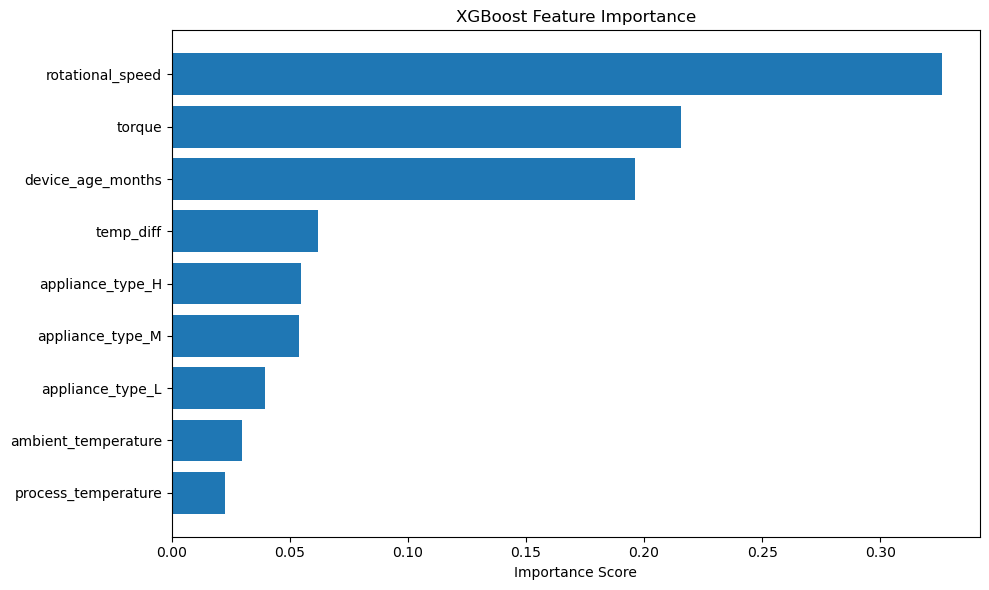

In [13]:
cat_encoder = preprocessor.named_transformers_['cat'].named_steps['onehot']
cat_feature_names = cat_encoder.get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(cat_feature_names)

feat_importance = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feat_importance['Feature'], feat_importance['Importance'])
plt.gca().invert_yaxis()
plt.title("XGBoost Feature Importance")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

In [14]:
X_full = df.drop(columns=cols_to_drop, errors='ignore')
X_all_processed = preprocessor.transform(X_full)

df['failure_risk_score'] = xgb_model.predict_proba(X_all_processed)[:, 1]

def risk_label(score):
    if score > 0.60:
        return 'High Risk'
    elif score > 0.30:
        return 'Medium Risk'
    else:
        return 'Low Risk'

df['risk_category'] = df['failure_risk_score'].apply(risk_label)

print(df[['failure_risk_score', 'risk_category', 'service_required']].head(10))
print("\nRisk Distribution:\n", df['risk_category'].value_counts())

   failure_risk_score risk_category  service_required
0            0.001048      Low Risk               0.0
1            0.004465      Low Risk               0.0
2            0.002620      Low Risk               0.0
3            0.002889      Low Risk               0.0
4            0.002025      Low Risk               0.0
5            0.002888      Low Risk               0.0
6            0.001102      Low Risk               0.0
7            0.001980      Low Risk               0.0
8            0.002515      Low Risk               0.0
9            0.001430      Low Risk               0.0

Risk Distribution:
 risk_category
Low Risk       9400
High Risk       403
Medium Risk     197
Name: count, dtype: int64


## PHASE 2 - ENEGY DATASET

In [15]:
energy = pd.read_csv('ape.csv', encoding='latin1')
energy = energy.rename(columns={energy.columns[0]: 'date'})
energy['date'] = pd.to_datetime(energy['date'], errors='coerce')
energy = energy.dropna(subset=['date'])

print("Energy Shape:", energy.shape)
energy.head()

Energy Shape: (19735, 29)


,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,T5,RH_5,T6,RH_6,T7,RH_7,T8,RH_8,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60.0,30.0,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,45.566667,17.166667,55.20,7.026667,84.256667,17.200000,41.626667,18.2,48.900000,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60.0,30.0,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,45.992500,17.166667,55.20,6.833333,84.063333,17.200000,41.560000,18.2,48.863333,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50.0,30.0,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,45.890000,17.166667,55.09,6.560000,83.156667,17.200000,41.433333,18.2,48.730000,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50.0,40.0,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,45.723333,17.166667,55.09,6.433333,83.423333,17.133333,41.290000,18.1,48.590000,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60.0,40.0,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,45.530000,17.200000,55.09,6.366667,84.893333,17.200000,41.230000,18.1,48.590000,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


In [16]:
energy['hour']        = energy['date'].dt.hour
energy['day_of_week'] = energy['date'].dt.dayofweek
energy['is_weekend']  = energy['day_of_week'].isin([5, 6]).astype(int)

energy = energy.rename(columns={
    'Appliances': 'power_consumption_wh',
    'T_out': 'ambient_temperature'
})

energy['power_consumption_kwh'] = energy['power_consumption_wh'] / 1000
print("✅ Energy features ready!")
energy.head()


✅ Energy features ready!


,date,power_consumption_wh,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,T5,RH_5,T6,RH_6,T7,RH_7,T8,RH_8,T9,RH_9,ambient_temperature,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2,hour,day_of_week,is_weekend,power_consumption_kwh
0,2016-01-11 17:00:00,60.0,30.0,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,45.566667,17.166667,55.20,7.026667,84.256667,17.200000,41.626667,18.2,48.900000,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433,17,0,0,0.06
1,2016-01-11 17:10:00,60.0,30.0,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,45.992500,17.166667,55.20,6.833333,84.063333,17.200000,41.560000,18.2,48.863333,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195,17,0,0,0.06
2,2016-01-11 17:20:00,50.0,30.0,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,45.890000,17.166667,55.09,6.560000,83.156667,17.200000,41.433333,18.2,48.730000,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668,17,0,0,0.05
3,2016-01-11 17:30:00,50.0,40.0,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,45.723333,17.166667,55.09,6.433333,83.423333,17.133333,41.290000,18.1,48.590000,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389,17,0,0,0.05
4,2016-01-11 17:40:00,60.0,40.0,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,45.530000,17.200000,55.09,6.366667,84.893333,17.200000,41.230000,18.1,48.590000,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097,17,0,0,0.06


In [17]:
energy['day'] = energy['date'].dt.date

energy_daily = energy.groupby('day').agg(
    power_consumption_kwh=('power_consumption_kwh', 'sum'),
    ambient_temperature=('ambient_temperature', 'mean'),
    usage_count=('hour', 'count')
).reset_index()

energy_daily['usage_hours_daily'] = energy_daily['usage_count'] / 60
energy_daily['energy_per_hour']   = (
    energy_daily['power_consumption_kwh'] / energy_daily['usage_hours_daily']
)
energy_daily = energy_daily.drop(columns=['usage_count'])

print("Daily energy shape:", energy_daily.shape)
energy_daily.head()

Daily energy shape: (138, 5)


,day,power_consumption_kwh,ambient_temperature,usage_hours_daily,energy_per_hour
0,2016-01-11,5.74,5.922619,0.7,8.200000
1,2016-01-12,12.34,5.566319,2.4,5.141667
2,2016-01-13,13.97,4.856944,2.4,5.820833
3,2016-01-14,21.80,3.431944,2.4,9.083333
4,2016-01-15,18.05,2.665278,2.4,7.520833


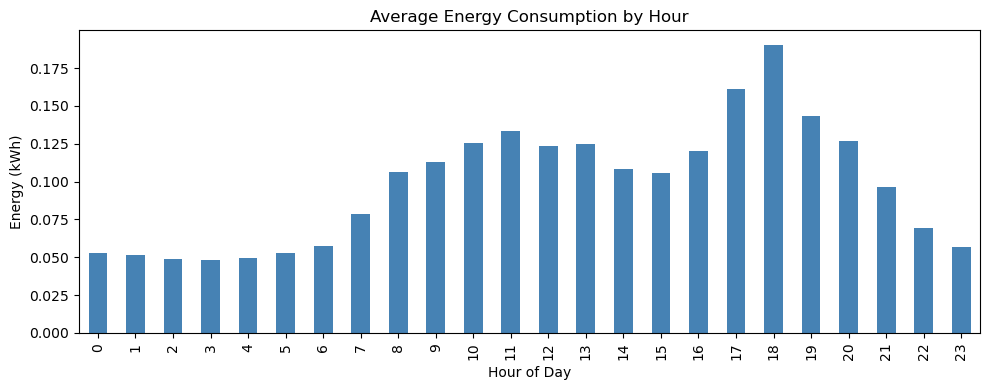

In [18]:
peak_hours = energy.groupby('hour')['power_consumption_kwh'].mean()

plt.figure(figsize=(10, 4))
peak_hours.plot(kind='bar', color='steelblue')
plt.title("Average Energy Consumption by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Energy (kWh)")
plt.tight_layout()
plt.show()

In [19]:
regions    = ['North', 'South', 'East', 'West']
appliances = ['AC', 'Washing Machine', 'Refrigerator']

energy_daily['device_id']      = np.arange(len(energy_daily))
energy_daily['region']         = np.random.choice(regions,    size=len(energy_daily))
energy_daily['appliance_type'] = np.random.choice(appliances, size=len(energy_daily))

print("✅ Business context added!")
energy_daily.head()

✅ Business context added!


,day,power_consumption_kwh,ambient_temperature,usage_hours_daily,energy_per_hour,device_id,region,appliance_type
0,2016-01-11,5.74,5.922619,0.7,8.200000,0,South,AC
1,2016-01-12,12.34,5.566319,2.4,5.141667,1,South,AC
2,2016-01-13,13.97,4.856944,2.4,5.820833,2,East,Washing Machine
3,2016-01-14,21.80,3.431944,2.4,9.083333,3,South,AC
4,2016-01-15,18.05,2.665278,2.4,7.520833,4,East,Refrigerator


## Phase 3 — Business KPIs

In [20]:
# Basic counts
total_devices  = len(df)
failed_devices = int(df['service_required'].sum())
failure_rate   = (failed_devices / total_devices) * 100
avg_risk       = df['failure_risk_score'].mean()
high_risk_devices = df[df['failure_risk_score'] > 0.60]

# Cost assumptions
reactive_cost  = 5000   # failure ke baad repair cost
preventive_cost = 1500  # advance service cost

# Prevented failures = High risk lekin abhi tak fail nahi hue
threshold_pct  = df['failure_risk_score'].quantile(0.9)
prevented      = df[
    (df['failure_risk_score'] > threshold_pct) &
    (df['service_required'] == 0)
]
prevented_failures = len(prevented)
cost_saved         = (reactive_cost - preventive_cost) * prevented_failures

print(f"Total Devices       : {total_devices:,}")
print(f"Failed Devices      : {failed_devices}")
print(f"Failure Rate        : {failure_rate:.2f}%")
print(f"High Risk Devices   : {len(high_risk_devices)}")
print(f"Avg Risk Score      : {avg_risk:.4f}")
print(f"Prevented Failures  : {prevented_failures}")
print(f"Estimated Cost Saved: ₹{cost_saved:,}")

Total Devices       : 10,000
Failed Devices      : 339
Failure Rate        : 3.39%
High Risk Devices   : 403
Avg Risk Score      : 0.0612
Prevented Failures  : 665
Estimated Cost Saved: ₹2,327,500


In [21]:
kpi_summary = pd.DataFrame({
    'Metric': [
        'Total Devices',
        'Failure Rate (%)',
        'High Risk Devices',
        'Avg Risk Score',
        'Prevented Failures',
        'Estimated Cost Saved (₹)'
    ],
    'Value': [
        total_devices,
        round(failure_rate, 2),
        len(high_risk_devices),
        round(avg_risk, 4),
        prevented_failures,
        cost_saved
    ]
})

kpi_summary

,Metric,Value
0,Total Devices,1.000000e+04
1,Failure Rate (%),3.390000e+00
2,High Risk Devices,4.030000e+02
3,Avg Risk Score,6.120000e-02
4,Prevented Failures,6.650000e+02
5,Estimated Cost Saved (₹),2.327500e+06


In [22]:
df = df.reset_index(drop=True)
df['device_id'] = df.index

# Energy dataset ko ML dataset size ke saath align karo
energy_aligned = energy_daily.sample(
    n=len(df), replace=True, random_state=42
).reset_index(drop=True)
energy_aligned['device_id'] = df['device_id']

# Merge on device_id
merged_df = pd.merge(df, energy_aligned, on='device_id', how='left',
                     suffixes=('', '_energy'))

print("Merged shape:", merged_df.shape)
merged_df.head()

Merged shape: (10000, 24)


,date,appliance_type,ambient_temperature,process_temperature,rotational_speed,torque,service_required,TWF,HDF,PWF,OSF,RNF,temp_diff,device_age_months,failure_risk_score,risk_category,device_id,day,power_consumption_kwh,ambient_temperature_energy,usage_hours_daily,energy_per_hour,region,appliance_type_energy
0,1,M,298.1,308.6,1551.0,42.8,0.0,0.0,0.0,0.0,0.0,0.0,10.5,0.000000,0.001048,Low Risk,0,2016-04-22,24.57,11.141667,2.4,10.237500,West,Refrigerator
1,2,L,298.2,308.7,1408.0,46.3,0.0,0.0,0.0,0.0,0.0,0.0,10.5,0.100000,0.004465,Low Risk,1,2016-04-12,15.90,10.648264,2.4,6.625000,West,Washing Machine
2,3,L,298.1,308.5,1498.0,49.4,0.0,0.0,0.0,0.0,0.0,0.0,10.4,0.166667,0.002620,Low Risk,2,2016-01-25,9.47,9.531597,2.4,3.945833,West,Washing Machine
3,4,L,298.2,308.6,1433.0,39.5,0.0,0.0,0.0,0.0,0.0,0.0,10.4,0.233333,0.002889,Low Risk,3,2016-04-26,10.66,3.793056,2.4,4.441667,West,Washing Machine
4,5,L,298.2,308.7,1408.0,40.0,0.0,0.0,0.0,0.0,0.0,0.0,10.5,0.300000,0.002025,Low Risk,4,2016-03-22,10.24,6.911806,2.4,4.266667,North,Refrigerator


In [23]:
merged_df.to_csv('lg_smartcare_data.csv', index=False)
print("✅ lg_smartcare_data.csv saved!")

✅ lg_smartcare_data.csv saved!


In [24]:
joblib.dump(preprocessor, 'lg_preprocessor.pkl')
joblib.dump(xgb_model,   'lg_predictive_maintenance_xgb.pkl')

print("✅ Model exported: lg_predictive_maintenance_xgb.pkl")
print("✅ Preprocessor exported: lg_preprocessor.pkl")

✅ Model exported: lg_predictive_maintenance_xgb.pkl
✅ Preprocessor exported: lg_preprocessor.pkl


In [25]:
import joblib
import sklearn
import xgboost
import platform

print("Python:", platform.python_version())
print("Scikit-learn:", sklearn.__version__)
print("XGBoost:", xgboost.__version__)

joblib.dump(preprocessor, 'lg_preprocessor.pkl')
joblib.dump(xgb_model, 'lg_predictive_maintenance_xgb.pkl')
print("Files saved!")

Python: 3.12.7
Scikit-learn: 1.5.1
XGBoost: 3.2.0
Files saved!


In [ ]:
!streamlit run app.py